# Régression logistique — baseline

Modèle **baseline** de classification des radios (COVID / Normal / Lung_Opacity / Viral Pneumonia)
à partir de 4 features tabulaires issues du preprocessing (masque + CLAHE).

Étapes : chargement des splits → standardisation → régression logistique → évaluation
(validation + test) → recherche d'hyperparamètres (`GridSearchCV`).

> **Note données** : les CSV splittés se trouvent dans le dossier `csv/` du projet
> (`train_features.csv`, `validation_features.csv`, `test_features.csv`).
> Colonne cible : `classe`. Features utilisées :
> `lum_interieur_masque`, `lum_exterieur_masque`, `surface_masque`, `variance_laplacien`.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# scikit-learn >= 1.8 emet des FutureWarning sur 'penalty' (deprecie) et un UserWarning
# lie a liblinear ; on les masque pour garder les sorties du GridSearch lisibles.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## 1. Chargement des CSV splittés

On charge les jeux **train / validation / test** déjà séparés par le pipeline, puis on
extrait les 4 features et la cible `classe`.

In [2]:
# Chemins des CSV splittés (dossier csv/ du projet)
train_csv = r"C:\Users\Maxime\Documents\Liora_Covid\csv\train_features.csv"
val_csv   = r"C:\Users\Maxime\Documents\Liora_Covid\csv\validation_features.csv"
test_csv  = r"C:\Users\Maxime\Documents\Liora_Covid\csv\test_features.csv"

df_train = pd.read_csv(train_csv)
df_val   = pd.read_csv(val_csv)
df_test  = pd.read_csv(test_csv)

FEATURES = ["lum_interieur_masque", "lum_exterieur_masque", "surface_masque", "variance_laplacien"]
TARGET   = "classe"

# Ordre de classes fixe (pour rapports et matrices de confusion cohérents)
LABELS = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

X_train, y_train = df_train[FEATURES], df_train[TARGET]
X_val,   y_val   = df_val[FEATURES],   df_val[TARGET]
X_test,  y_test  = df_test[FEATURES],  df_test[TARGET]

print("Train :", X_train.shape, "| Val :", X_val.shape, "| Test :", X_test.shape)
print("\\nRépartition des classes (train) :")
print(y_train.value_counts())

Train : (16668, 4) | Val : (2083, 4) | Test : (2084, 4)
\nRépartition des classes (train) :
classe
Normal             8109
Lung_Opacity       4791
COVID              2698
Viral Pneumonia    1070
Name: count, dtype: int64


## 2. Standardisation des features

`StandardScaler` est **ajusté (`fit`) uniquement sur le train**, puis appliqué (`transform`)
sur train / val / test afin d'éviter toute fuite d'information.

In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit uniquement sur le train
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Moyennes (train, après scaling) :", np.round(X_train_scaled.mean(axis=0), 4))
print("Écarts-types (train, après scaling) :", np.round(X_train_scaled.std(axis=0), 4))

Moyennes (train, après scaling) : [ 0. -0.  0.  0.]
Écarts-types (train, après scaling) : [1. 1. 1. 1.]


## 3. Entraînement de la régression logistique

`LogisticRegression` avec `max_iter=1000` et `class_weight='balanced'` pour compenser
le fort déséquilibre des classes (Normal très majoritaire, Viral Pneumonia minoritaire).

In [4]:
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train_scaled, y_train)

print("Modèle entraîné.")
print("Classes :", list(logreg.classes_))

Modèle entraîné.
Classes : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


## 4. Évaluation (validation et test)

Pour chaque jeu : `accuracy_score`, `classification_report` (precision / recall / f1 par classe)
et matrice de confusion via `ConfusionMatrixDisplay`.

In [5]:
def evaluer(model, X, y, titre, labels=LABELS):
    """Affiche accuracy, classification_report et matrice de confusion."""
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)

    print(f"===== {titre} =====")
    print(f"Accuracy : {acc:.4f}\n")
    print(classification_report(y, y_pred, labels=labels, zero_division=0))

    cm = confusion_matrix(y, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
        cmap="Blues", xticks_rotation=45, ax=ax, colorbar=False
    )
    ax.set_title(f"Matrice de confusion — {titre}")
    plt.tight_layout()
    plt.show()
    return acc

===== Régression logistique — Validation =====
Accuracy : 0.4633

                 precision    recall  f1-score   support

          COVID       0.18      0.21      0.20       338
   Lung_Opacity       0.55      0.50      0.52       598
         Normal       0.68      0.49      0.57      1013
Viral Pneumonia       0.24      0.73      0.36       134

       accuracy                           0.46      2083
      macro avg       0.41      0.48      0.41      2083
   weighted avg       0.53      0.46      0.48      2083



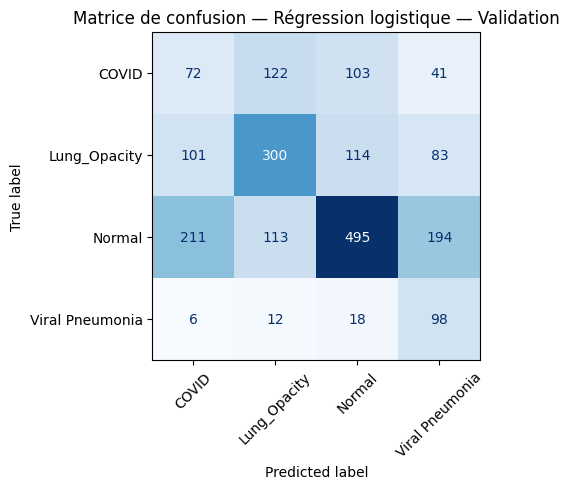

===== Régression logistique — Test =====
Accuracy : 0.4621

                 precision    recall  f1-score   support

          COVID       0.19      0.24      0.21       337
   Lung_Opacity       0.54      0.52      0.53       599
         Normal       0.69      0.46      0.56      1014
Viral Pneumonia       0.24      0.77      0.37       134

       accuracy                           0.46      2084
      macro avg       0.42      0.50      0.42      2084
   weighted avg       0.54      0.46      0.48      2084



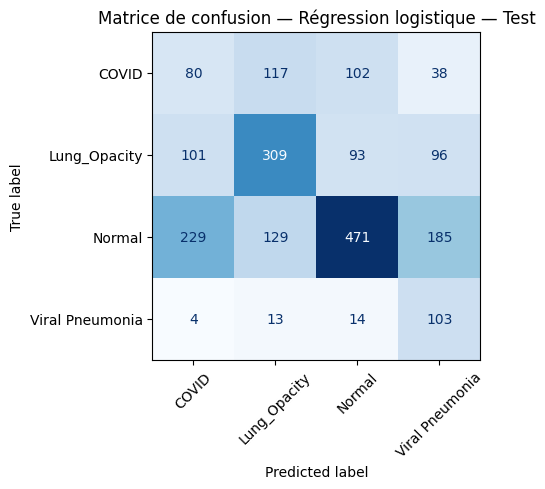

In [6]:
acc_val  = evaluer(logreg, X_val_scaled,  y_val,  "Régression logistique — Validation")
acc_test = evaluer(logreg, X_test_scaled, y_test, "Régression logistique — Test")

## 5. Recherche d'hyperparamètres (`GridSearchCV`)

Validation croisée `cv=5` sur le **train** pour trouver la meilleure combinaison de
`C`, `penalty` et `solver`, en optimisant le **f1 macro** (adapté au déséquilibre des classes).

> **Adaptation scikit-learn ≥ 1.8** : `liblinear` (le solveur compatible `l1`/`l2`) ne gère
> plus directement le multiclasse (4 classes ici). On l'enveloppe donc dans un
> `OneVsRestClassifier` (un modèle binaire liblinear par classe) — c'est le schéma
> *one-vs-rest* que les anciennes versions appliquaient automatiquement, et la solution
> recommandée par scikit-learn. Les hyperparamètres sont donc préfixés `estimator__`.

In [7]:
# liblinear enveloppe dans OneVsRestClassifier (multiclasse en one-vs-rest)
base_estimator = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")
)

param_grid = {
    "estimator__C": [0.01, 0.1, 1, 10, 100],
    "estimator__penalty": ["l1", "l2"],
    "estimator__solver": ["liblinear"],
}

grid = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train_scaled, y_train)

print("Meilleurs hyperparamètres :", grid.best_params_)
print(f"Meilleur score CV (f1_macro) : {grid.best_score_:.4f}")

best_model = grid.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Meilleurs hyperparamètres : {'estimator__C': 0.1, 'estimator__penalty': 'l2', 'estimator__solver': 'liblinear'}
Meilleur score CV (f1_macro) : 0.4301


### Évaluation du meilleur modèle (validation et test)

Mêmes métriques qu'au point 4, appliquées au modèle retenu par `GridSearchCV`.

===== Meilleur modèle (GridSearch) — Validation =====
Accuracy : 0.5151

                 precision    recall  f1-score   support

          COVID       0.21      0.12      0.16       338
   Lung_Opacity       0.53      0.56      0.55       598
         Normal       0.68      0.60      0.63      1013
Viral Pneumonia       0.25      0.67      0.37       134

       accuracy                           0.52      2083
      macro avg       0.42      0.49      0.43      2083
   weighted avg       0.53      0.52      0.51      2083



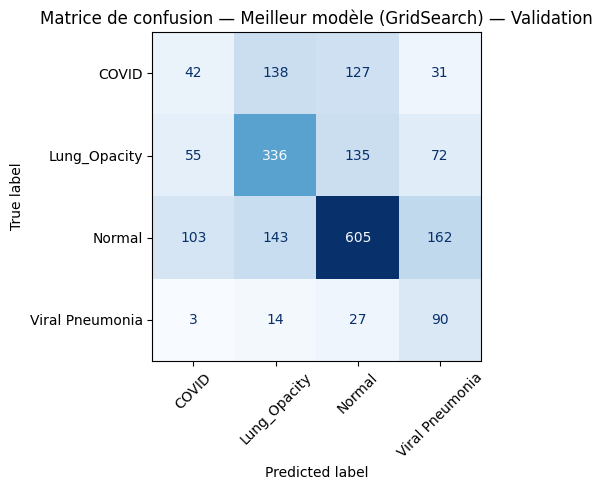

===== Meilleur modèle (GridSearch) — Test =====
Accuracy : 0.5173

                 precision    recall  f1-score   support

          COVID       0.22      0.14      0.17       337
   Lung_Opacity       0.52      0.58      0.55       599
         Normal       0.70      0.58      0.63      1014
Viral Pneumonia       0.26      0.72      0.38       134

       accuracy                           0.52      2084
      macro avg       0.43      0.50      0.43      2084
   weighted avg       0.54      0.52      0.52      2084



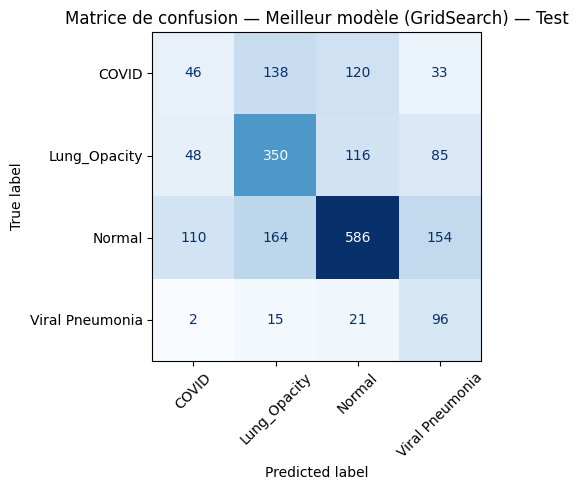

Récapitulatif des accuracies
  Baseline        -> val: 0.4633 | test: 0.4621
  Meilleur modèle -> val: 0.5151 | test: 0.5173


In [8]:
acc_val_best  = evaluer(best_model, X_val_scaled,  y_val,  "Meilleur modèle (GridSearch) — Validation")
acc_test_best = evaluer(best_model, X_test_scaled, y_test, "Meilleur modèle (GridSearch) — Test")

print("Récapitulatif des accuracies")
print(f"  Baseline        -> val: {acc_val:.4f} | test: {acc_test:.4f}")
print(f"  Meilleur modèle -> val: {acc_val_best:.4f} | test: {acc_test_best:.4f}")

## 6. Comparaison : régression logistique avec vs sans pondération

On entraîne **deux versions** de la régression logistique, identiques en tout point sauf
le paramètre `class_weight`, toutes deux enveloppées dans `OneVsRestClassifier` :

1. **Sans pondération** : `LogisticRegression(max_iter=1000)` — le modèle « brut ».
2. **Avec pondération** : `LogisticRegression(max_iter=1000, class_weight="balanced")` —
   les classes rares reçoivent un poids plus élevé.

Pour chaque version, on affiche sur le **jeu de test** : `accuracy_score`,
`classification_report` (precision / recall / f1 par classe) et la matrice de confusion
(`ConfusionMatrixDisplay`), puis un tableau comparatif du recall par classe.

===== LogReg SANS ponderation — Test =====


Accuracy : 0.5998



                 precision    recall  f1-score   support

          COVID       0.00      0.00      0.00       337
   Lung_Opacity       0.54      0.58      0.56       599
         Normal       0.63      0.87      0.73      1014
Viral Pneumonia       0.50      0.13      0.21       134

       accuracy                           0.60      2084
      macro avg       0.42      0.40      0.38      2084
   weighted avg       0.49      0.60      0.53      2084



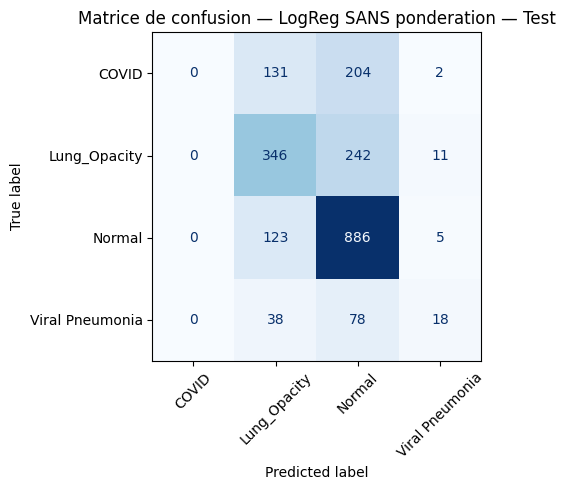

===== LogReg AVEC ponderation (balanced) — Test =====
Accuracy : 0.5192

                 precision    recall  f1-score   support

          COVID       0.23      0.14      0.17       337
   Lung_Opacity       0.52      0.58      0.55       599
         Normal       0.70      0.58      0.63      1014
Viral Pneumonia       0.26      0.72      0.38       134

       accuracy                           0.52      2084
      macro avg       0.43      0.50      0.44      2084
   weighted avg       0.54      0.52      0.52      2084



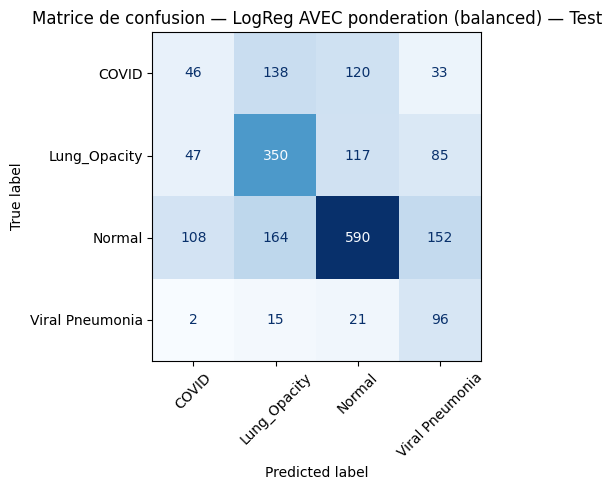


================ COMPARAISON ================
Accuracy globale  ->  sans pondération : 0.5998  |  balanced : 0.5192

Recall par classe (jeu de test) :
                 recall — sans pondération  recall — balanced
COVID                               0.0000             0.1365
Lung_Opacity                        0.5776             0.5843
Normal                              0.8738             0.5819
Viral Pneumonia                     0.1343             0.7164


In [9]:
# --- Deux versions de la regression logistique, enveloppees dans OneVsRestClassifier ---
# 1) sans ponderation  2) avec class_weight='balanced'
logreg_sans = OneVsRestClassifier(LogisticRegression(max_iter=1000))
logreg_pond = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight="balanced"))

logreg_sans.fit(X_train_scaled, y_train)
logreg_pond.fit(X_train_scaled, y_train)

# Evaluation sur le TEST : accuracy, classification_report, matrice de confusion
acc_sans = evaluer(logreg_sans, X_test_scaled, y_test, "LogReg SANS ponderation — Test")
acc_pond = evaluer(logreg_pond, X_test_scaled, y_test, "LogReg AVEC ponderation (balanced) — Test")

# --- Tableau comparatif : accuracy globale + recall par classe ---
from sklearn.metrics import recall_score

rec_sans = recall_score(y_test, logreg_sans.predict(X_test_scaled), labels=LABELS, average=None, zero_division=0)
rec_pond = recall_score(y_test, logreg_pond.predict(X_test_scaled), labels=LABELS, average=None, zero_division=0)

comparatif = pd.DataFrame(
    {"recall — sans pondération": rec_sans, "recall — balanced": rec_pond},
    index=LABELS,
).round(4)

print("\n================ COMPARAISON ================")
print(f"Accuracy globale  ->  sans pondération : {acc_sans:.4f}  |  balanced : {acc_pond:.4f}\n")
print("Recall par classe (jeu de test) :")
print(comparatif)

## 7. Conclusion — compromis accuracy globale vs équité entre classes

Les deux modèles partagent exactement le même algorithme (régression logistique
`OneVsRestClassifier`, `max_iter=1000`) et ne diffèrent que par le paramètre
`class_weight`. Résultats sur le **jeu de test** :

| Métrique | Sans pondération | Avec pondération (`balanced`) |
|---|---|---|
| **Accuracy globale** | **0.5998** | 0.5192 |
| Recall **COVID** | **0.0000** | **0.1365** |
| Recall Lung_Opacity | 0.5776 | 0.5843 |
| Recall Normal | 0.8738 | 0.5819 |
| Recall **Viral Pneumonia** | 0.1343 | **0.7164** |

**Lecture du compromis :**

- **Sans pondération**, le modèle obtient la meilleure *accuracy globale* (~0.60), mais
  au prix d'un effondrement sur les classes minoritaires : il **ne prédit jamais COVID**
  (recall = 0) et rate l'immense majorité des *Viral Pneumonia* (recall ≈ 0.13). L'accuracy
  est élevée simplement parce qu'il se rabat sur les classes majoritaires *Normal*
  (recall 0.87) et *Lung_Opacity*. C'est un modèle **inéquitable** : flatteur en apparence,
  inutile pour détecter les pathologies rares.

- **Avec pondération `balanced`**, l'accuracy globale baisse (~0.52) car le modèle « sacrifie »
  des *Normal* bien classés (recall 0.87 → 0.58), mais il devient **beaucoup plus équitable
  entre classes** : le recall COVID passe de 0.00 à 0.14 et surtout le recall *Viral Pneumonia*
  bondit de 0.13 à **0.72**.

**Conclusion :** l'accuracy globale seule est un mauvais juge sur des données déséquilibrées.
Dans un contexte médical où **manquer un COVID ou une pneumonie virale** (faux négatifs) est
bien plus grave que sur-alerter, la version pondérée est préférable malgré son accuracy plus
basse. Le bon critère de sélection reste le **f1 macro / recall par classe**, comme utilisé
dans le `GridSearchCV` de la section 5.

> Les valeurs ci-dessus sont recopiées des sorties exécutées ; elles se recalculent
> automatiquement à chaque *Run All* et peuvent varier légèrement selon la version de scikit-learn.